# Assignment: Using Pretrained EfficientNetB7

# Imports

In [2]:
!pip uninstall tf-keras
!pip install tensorflow==2.16.1

In [4]:
!pip install ml_dtypes==0.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 48.8 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tf-keras>=2.18.0, which is not installed.
tensorflow 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.16.1 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.16.1 which is incompatible.


In [1]:
# !pip uninstall tf-keras
# !pip install keras-tuner
# !pip install tensorflow==2.16.1
# !pip install ml_dtypes==0.5

Found existing installation: tf_keras 2.20.0
Uninstalling tf_keras-2.20.0:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/tf_keras-2.20.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/tf_keras/*
Proceed (Y/n)? y
  Successfully uninstalled tf_keras-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Atte

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 50.4 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import keras
import tensorflow as tf
print("Keras Current Version:", keras.__version__, "Tensorflow Current Version:", tf.__version__)

Keras Current Version: 3.13.2 Tensorflow Current Version: 2.16.1


In [2]:
from glob import glob
import random, os, datetime

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import Input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import plot_model

# Functions

In [3]:
def get_image_paths(root_dir, num_images=None):
    all_images = []
    for extension in ['*.jpg', '*.jpeg', '*.png']:
        all_images.extend(glob(os.path.join(root_dir, '**', extension), recursive=True))
    if num_images is None:
        return all_images
    else:
        return random.sample(all_images, min(num_images, len(all_images)))

def display_images(img_list):
    plt.figure(figsize=(15, 6))
    for i, img_path in enumerate(img_list):
        img = image.load_img(img_path)
        img = image.img_to_array(img, dtype=np.uint8)
        plt.subplot(2, 5, i + 1)
        plt.imshow(img.squeeze())
        plt.axis('off')
        plt.title(f'Image {i+1}')
    plt.tight_layout()
    plt.show()


def print_predicted_classes(predicted_classes):
    for full_path, (label, probability) in predicted_classes.items():
        filename = os.path.basename(full_path)
        print(f"{filename}: {label} ({probability:.2f}%)")

# Task 1: Google Drive ya da local ortamınızdan imagenet_samples klasörünün dizinini okuyunuz.

# Task 1 Solution

In [4]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [6]:
dir_path = "/content/drive/MyDrive/Colab Notebooks/CNN/datasets_and_files/imagenet_samples"

# Task 2: Bu dizinden 10 tane resim çekiniz ve gösteriniz.

# Task 2 Solution

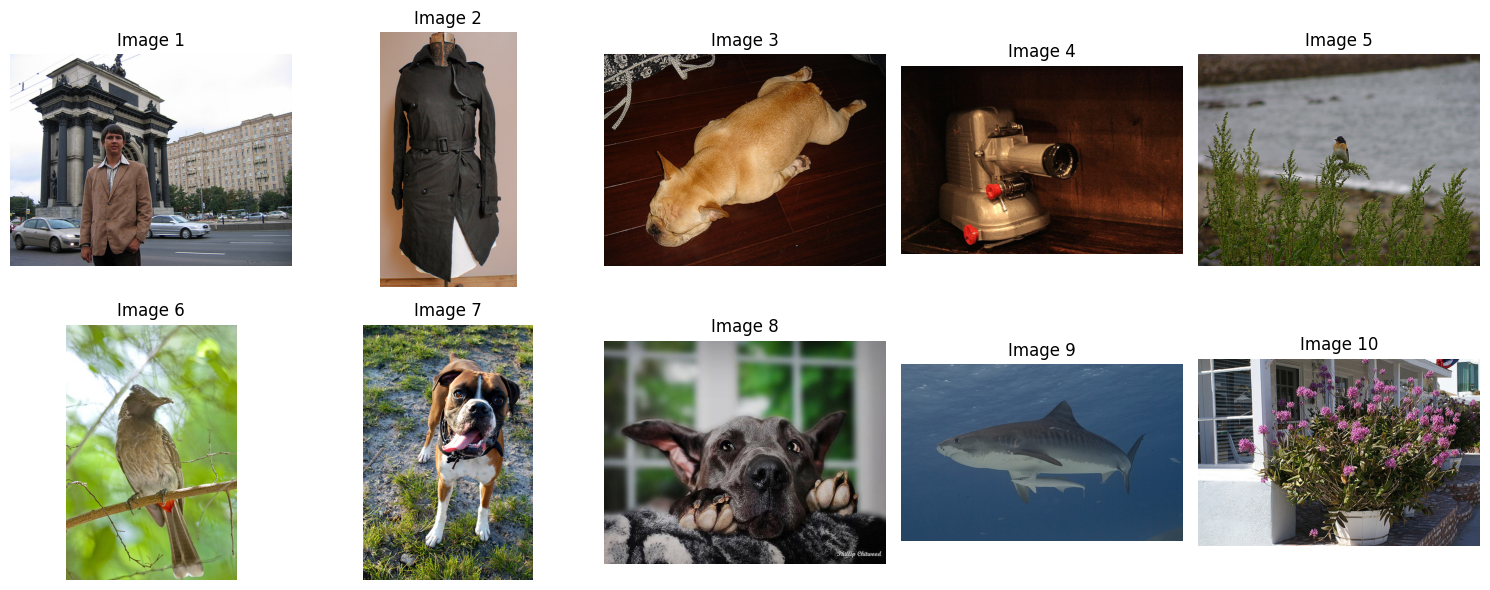

In [9]:
img_list = get_image_paths(dir_path, 10)
display_images(img_list)

# Task 3: EfficientNetB7 modelini, preprocess metodunu ve decode metodunu çalışma ortamına getiriniz.

# Task 3 Solution

In [14]:
from keras.applications.efficientnet import EfficientNetB7, preprocess_input, decode_predictions

# Task 4: Preprocess fonksiyonunu yazınız (target_size= (600, 600))

# Task 4 Solution

In [10]:
def preprocess_EfficientNetB7 (img_path):

  img = image.load_img(img_path, target_size=(600,600))

  img = image.img_to_array(img)

  img = np.expand_dims(img, axis=0)

  img = preprocess_input(img)

  return img

# Task 5: Prediction fonksiyonunu yazınız.

# Task 5 Solution

In [11]:
def predict_EfficientNetB7 (model, img):

  predictions = model.predict(img, verbose=0)

  top_predictions = decode_predictions(predictions, top=1)[0][0]

  label, probability = top_predictions[1], top_predictions[2]

  return label, probability

# Task 6: Tahminleri görselleştirme fonksiyonunu yazınız

# Task 6 Solution

In [24]:
def visualize_predictions_EfficientNetB7(model, img_paths):
  predictions = {}

  for img_path in img_paths:
    img = preprocess_EfficientNetB7(img_path)
    label, probability = predict_EfficientNetB7(model, img)
    predictions[img_path] = (label, probability)



  plt.figure(figsize=(5, 5))
  plt.imshow(image.load_img(img_path))
  plt.title(f"Predicted: {label} ({probability:.2f}%)")
  plt.axis('off')
  plt.show()

  return predictions


# Task 7: EfficientNetB7 modelini çağırınız.

# Task 7 Solution

In [15]:
model_EfficentNetB7 = EfficientNetB7(weights='imagenet')

268326632/268326632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


# Task 8: Dizinde yer alan resimler için tahminleri görselleştirerek elde ediniz.

# Task 8 Solution

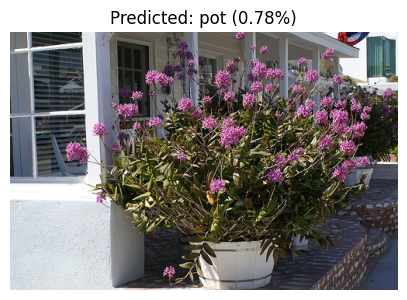

In [25]:
predicted_classes = visualize_predictions_EfficientNetB7(model_EfficentNetB7, img_list)

In [26]:
import os

def print_predicted_classes(predicted_classes):
    for full_path, (label, probability) in predicted_classes.items():
        filename = os.path.basename(full_path)
        print(f"{filename}: {label} ({probability:.2f}%)")

print_predicted_classes(predicted_classes)

triumphal_arch.jpeg: triumphal_arch (0.82%)
trench_coat.jpeg: trench_coat (0.80%)
French_bulldog.jpeg: French_bulldog (0.82%)
projector.jpeg: projector (0.84%)
brambling.jpeg: brambling (0.85%)
bulbul.jpeg: bulbul (0.80%)
boxer.jpeg: boxer (0.82%)
Great_Dane.jpeg: Great_Dane (0.77%)
tiger_shark.jpeg: tiger_shark (0.82%)
pot.jpeg: pot (0.78%)
